# 01 — UCI Beijing Multi-Site: predictive EDA

**Nguồn:** [UCI Beijing Multi-Site Air Quality](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data),
12 trạm, dữ liệu theo giờ 2013–2017.

Notebook trả lời sáu câu hỏi dùng chung cho cả benchmark:

1. Dữ liệu thiếu và lệch phân phối ở đâu?
2. Future level khác future change như thế nào?
3. Có precursor cho spike onset không?
4. Trạng thái trạm khác có ích hơn lịch sử riêng không?
5. Khí tượng/calendar tạo regime nào?
6. Validation và test có cùng độ khó không?

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
RNG = np.random.default_rng(42)

from benchmark_eda.data import load_raw_frames, RAW_FEATURES

raw_dir = ROOT / "data/raw/PRSA_Data_20130301-20170228"
df = load_raw_frames(raw_dir).sort_values(["station", "timestamp"]).copy()
group = df.groupby("station", sort=False)
for lag in [1, 3, 6, 12, 24]:
    df[f"PM_trend_{lag}h"] = df["PM2.5"] - group["PM2.5"].shift(lag)
for horizon in range(1, 7):
    df[f"PM_future_{horizon}h"] = group["PM2.5"].shift(-horizon)
    df[f"PM_delta_{horizon}h"] = df[f"PM_future_{horizon}h"] - df["PM2.5"]

overview = pd.Series({
    "rows": len(df), "stations": df.station.nunique(),
    "start": df.timestamp.min(), "end": df.timestamp.max(),
    "PM2.5 missing %": df["PM2.5"].isna().mean() * 100,
    "duplicate station-hours": df.duplicated(["station", "timestamp"]).sum(),
})
overview

rows                                    420768
stations                                    12
start                      2013-03-01 00:00:00
end                        2017-02-28 23:00:00
PM2.5 missing %                       2.076916
duplicate station-hours                      0
dtype: object

## Data quality, heterogeneity và seasonality

,missing_pct
CO,4.92
O3,3.16
NO2,2.88
SO2,2.14
PM2.5,2.08
PM10,1.53
DEWP,0.10
TEMP,0.09
PRES,0.09
RAIN,0.09


,count,mean,median,p90,p99
station,,,,,
Dongsi,34314,86.2,61.0,201.0,396.0
Wanshouxigong,34368,85.0,60.0,195.0,397.3
Nongzhanguan,34436,84.8,59.0,197.0,394.0
Gucheng,34418,83.9,60.0,190.0,381.0
Wanliu,34682,83.4,59.0,191.0,376.0
Guanyuan,34448,82.9,59.0,187.3,377.0
Aotizhongxin,34139,82.8,58.0,188.0,377.0
Tiantan,34387,82.2,59.0,189.0,369.0
Shunyi,34151,79.5,55.0,184.0,373.5


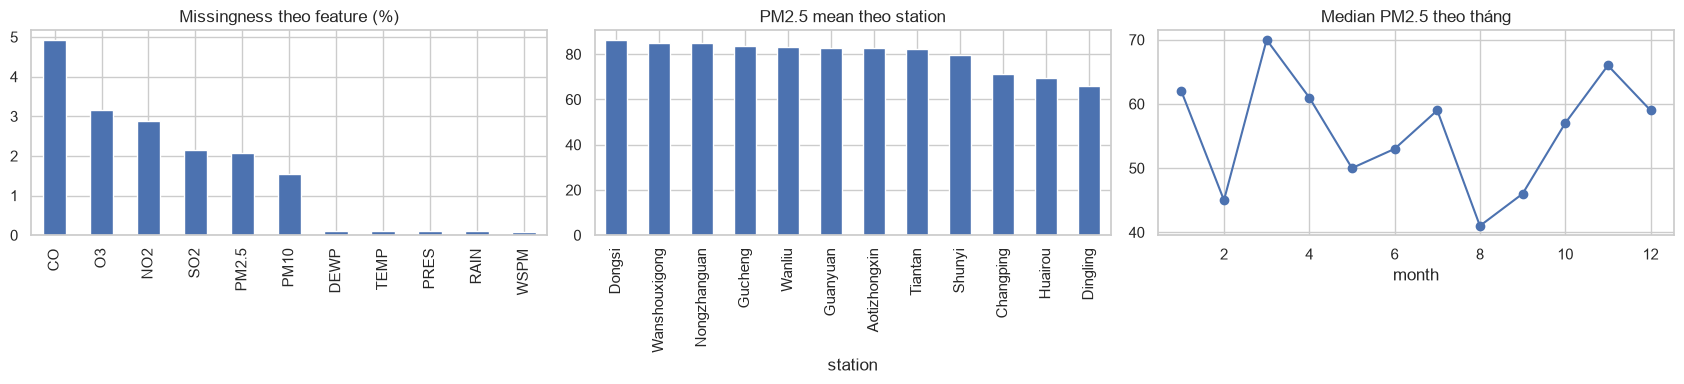

In [2]:
missing = df[RAW_FEATURES].isna().mean().mul(100).sort_values(ascending=False)
station_pm = df.groupby("station")["PM2.5"].agg(
    count="count", mean="mean", median="median",
    p90=lambda x: x.quantile(.9), p99=lambda x: x.quantile(.99)
).sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
missing.plot.bar(ax=axes[0], title="Missingness theo feature (%)")
station_pm["mean"].plot.bar(ax=axes[1], title="PM2.5 mean theo station")
df.assign(month=df.timestamp.dt.month).groupby("month")["PM2.5"].median().plot(
    marker="o", ax=axes[2], title="Median PM2.5 theo tháng"
)
plt.tight_layout()
display(missing.round(2).to_frame("missing_pct"))
display(station_pm.round(1))

## Persistence không đồng nghĩa với dự báo được transition

,1,3,6
PM2.5,-0.048,-0.119,-0.201
PM10,0.009,-0.086,-0.184
PM_trend_12h,-0.004,-0.080,-0.162
CO,0.004,-0.077,-0.160
PM_trend_24h,-0.002,-0.052,-0.102
PM_trend_6h,0.060,-0.018,-0.099
NO2,0.049,-0.017,-0.096
O3,-0.005,0.032,0.078
RAIN,-0.050,-0.060,-0.057
DEWP,0.014,-0.010,-0.052


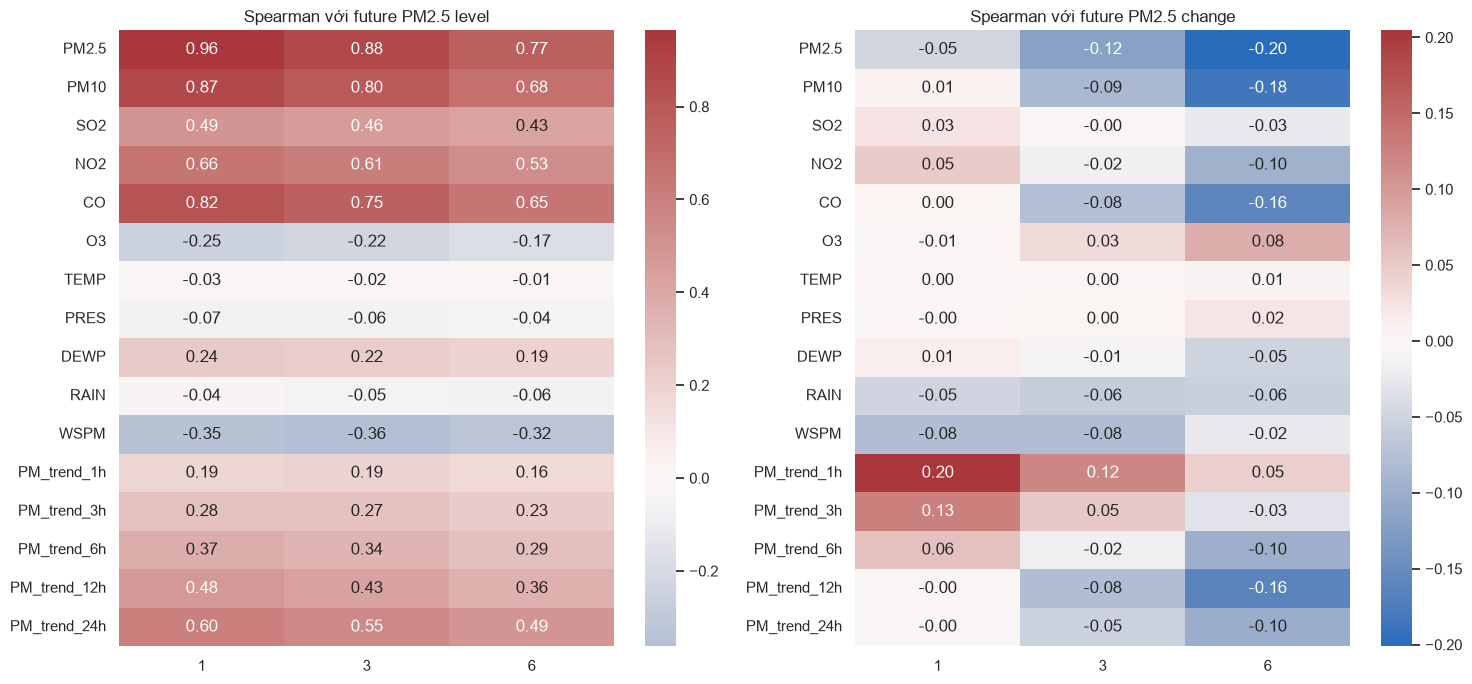

In [3]:
predictors = RAW_FEATURES + [f"PM_trend_{lag}h" for lag in [1, 3, 6, 12, 24]]
level_corr, delta_corr = {}, {}
for horizon in [1, 3, 6]:
    cols = predictors + [f"PM_future_{horizon}h", f"PM_delta_{horizon}h"]
    corr = df[cols].corr(method="spearman")
    level_corr[horizon] = corr[f"PM_future_{horizon}h"].loc[predictors]
    delta_corr[horizon] = corr[f"PM_delta_{horizon}h"].loc[predictors]
level_corr, delta_corr = pd.DataFrame(level_corr), pd.DataFrame(delta_corr)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.heatmap(level_corr, cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Spearman với future PM2.5 level")
sns.heatmap(delta_corr, cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman với future PM2.5 change")
plt.tight_layout()
display(delta_corr.reindex(delta_corr[6].abs().sort_values(ascending=False).index).round(3))

## Spike onset: kiểm soát theo mức PM hiện tại

,count,sum,mean,rate_pct
relative_level_bin,,,,
"[0.0, 0.25)",174915,769,0.004,0.440
"[0.25, 0.5)",95743,2241,0.023,2.341
"[0.5, 0.75)",55864,5762,0.103,10.314
"[0.75, 1.0)",30373,12146,0.400,39.989


,hours
0.50,4.0
0.75,11.0
0.90,23.0
0.95,36.0
1.00,102.0


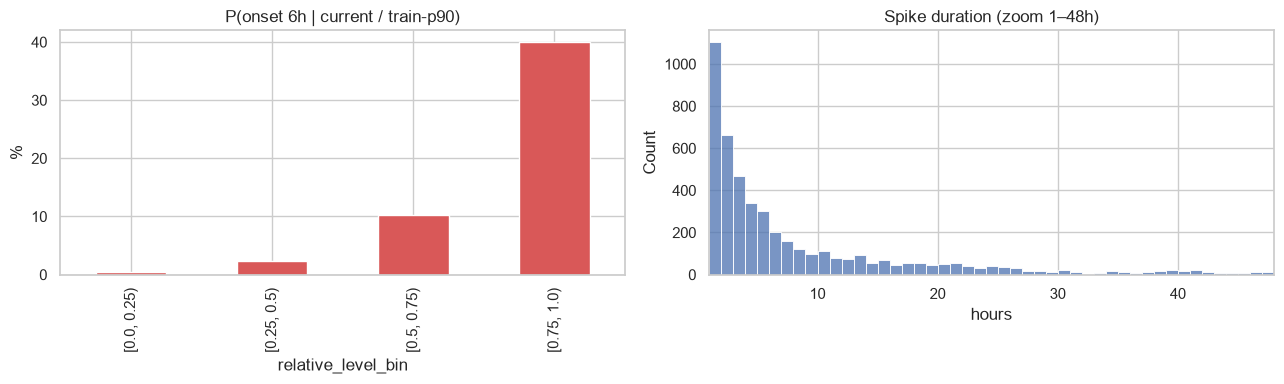

In [4]:
timestamps = np.sort(df.timestamp.unique())
train_end = timestamps[int(len(timestamps) * .70)]
threshold = df.loc[df.timestamp < train_end, "PM2.5"].quantile(.90)
future_cols = [f"PM_future_{h}h" for h in range(1, 7)]
eligible = df["PM2.5"].lt(threshold) & df[future_cols].notna().all(axis=1)
df["onset_next6"] = df[future_cols].ge(threshold).any(axis=1) & df["PM2.5"].lt(threshold)
relative_bins = [0, .25, .50, .75, 1.0]
df["relative_level_bin"] = pd.cut(
    df["PM2.5"] / threshold, relative_bins, right=False
)
onset_by_level = (
    df.loc[eligible].groupby("relative_level_bin", observed=True)["onset_next6"]
    .agg(["count", "sum", "mean"])
)

episode_lengths = []
for _, station_frame in df.groupby("station"):
    flag = station_frame["PM2.5"].ge(threshold).fillna(False).to_numpy()
    starts = np.where(flag & ~np.r_[False, flag[:-1]])[0]
    ends = np.where(flag & ~np.r_[flag[1:], False])[0]
    episode_lengths.extend((ends - starts + 1).tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
onset_by_level["mean"].mul(100).plot.bar(ax=axes[0], color="#D95858")
axes[0].set(title="P(onset 6h | current / train-p90)", ylabel="%")
sns.histplot(episode_lengths, bins=range(1, 49), ax=axes[1])
axes[1].set(title="Spike duration (zoom 1–48h)", xlabel="hours", xlim=(1, 48))
plt.tight_layout()
display(onset_by_level.assign(rate_pct=onset_by_level["mean"] * 100).round(3))
display(pd.Series(episode_lengths).quantile([.5, .75, .9, .95, 1]).to_frame("hours"))

## Spatial context và lead–lag

In [5]:
wide_pm = df.pivot(index="timestamp", columns="station", values="PM2.5").sort_index()
valid_count = wide_pm.notna().sum(axis=1)
city_sum = wide_pm.sum(axis=1, min_count=2)
spatial_rows = []
for station in wide_pm:
    own = wide_pm[station]
    other = (city_sum - own) / (valid_count - 1)
    for horizon in [1, 3, 6]:
        future_delta = own.shift(-horizon) - own
        signals = {
            "own level": own, "own trend 1h": own.diff(),
            "other-station level": other,
            "other-station trend 1h": other.diff(),
            "spatial gap (other-own)": other - own,
        }
        for name, values in signals.items():
            spatial_rows.append(
                (station, horizon, name, values.corr(future_delta, method="spearman"))
            )
spatial_signal = pd.DataFrame(
    spatial_rows, columns=["station", "horizon", "signal", "rho"]
)
spatial_summary = spatial_signal.groupby(["horizon", "signal"]).rho.agg(["mean", "std"])

delta_wide = wide_pm.diff()
best_leads = []
for source in delta_wide:
    for target in delta_wide:
        if source == target:
            continue
        correlations = {
            lead: delta_wide[source].corr(delta_wide[target].shift(-lead), method="spearman")
            for lead in range(7)
        }
        best_leads.append(max(correlations, key=lambda lag: abs(correlations[lag])))
display(spatial_summary.round(3))
display(pd.Series(best_leads).value_counts().sort_index().to_frame("station_pairs"))

mean    std
horizon signal                               
1       other-station level      0.018  0.008
        other-station trend 1h   0.325  0.082
        own level               -0.050  0.013
        own trend 1h             0.203  0.057
        spatial gap (other-own)  0.210  0.037
3       other-station level     -0.035  0.024
        other-station trend 1h   0.294  0.043
        own level               -0.122  0.017
        own trend 1h             0.118  0.040
        spatial gap (other-own)  0.289  0.036
6       other-station level     -0.117  0.040
        other-station trend 1h   0.198  0.023
        own level               -0.203  0.025
        own trend 1h             0.044  0.025
        spatial gap (other-own)  0.301  0.026

,station_pairs
0,118
1,9
2,5


## Regime khí tượng và distribution shift

,count,mean,rate_pct
wd,,,
E,23815,0.088,8.801
SE,16678,0.087,8.748
ESE,19541,0.086,8.587
SSE,14861,0.084,8.438
ENE,27249,0.082,8.169
S,16497,0.075,7.474
SSW,19733,0.064,6.390
SW,25504,0.061,6.125
WSW,17537,0.059,5.868


,PM_mean,PM_p99,delta6_abs_p90,onset6_pct
split,,,,
test,84.72,435.0,88.0,6.52
train,80.38,347.0,77.0,6.07
val,72.11,406.0,71.0,4.25


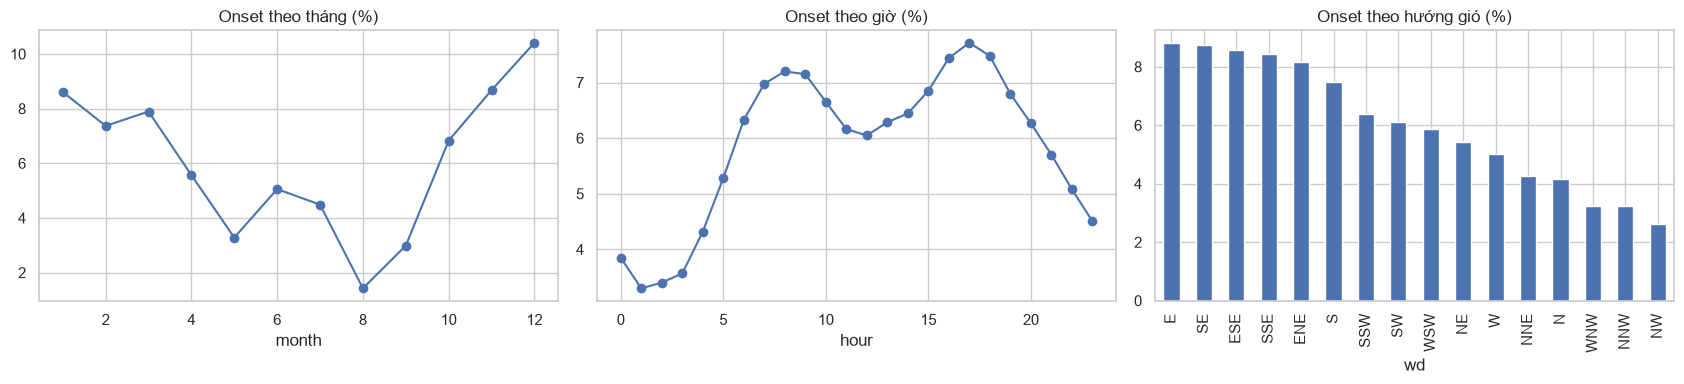

In [6]:
df["month"] = df.timestamp.dt.month
df["hour"] = df.timestamp.dt.hour
onset_month = df.loc[eligible].groupby("month")["onset_next6"].mean() * 100
onset_hour = df.loc[eligible].groupby("hour")["onset_next6"].mean() * 100
onset_wind = (
    df.loc[eligible].groupby("wd")["onset_next6"].agg(["count", "mean"])
    .query("count > 1000").sort_values("mean", ascending=False)
)

val_end = timestamps[int(len(timestamps) * .85)]
df["split"] = np.where(
    df.timestamp < train_end, "train",
    np.where(df.timestamp < val_end, "val", "test")
)
shift = df.groupby("split").agg(
    PM_mean=("PM2.5", "mean"),
    PM_p99=("PM2.5", lambda x: x.quantile(.99)),
    delta6_abs_p90=("PM_delta_6h", lambda x: x.abs().quantile(.90)),
)
shift["onset6_pct"] = (
    df.loc[eligible].groupby("split")["onset_next6"].mean() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
onset_month.plot(marker="o", ax=axes[0], title="Onset theo tháng (%)")
onset_hour.plot(marker="o", ax=axes[1], title="Onset theo giờ (%)")
onset_wind["mean"].mul(100).plot.bar(ax=axes[2], title="Onset theo hướng gió (%)")
plt.tight_layout()
display(onset_wind.assign(rate_pct=onset_wind["mean"] * 100).round(3))
display(shift.round(2))

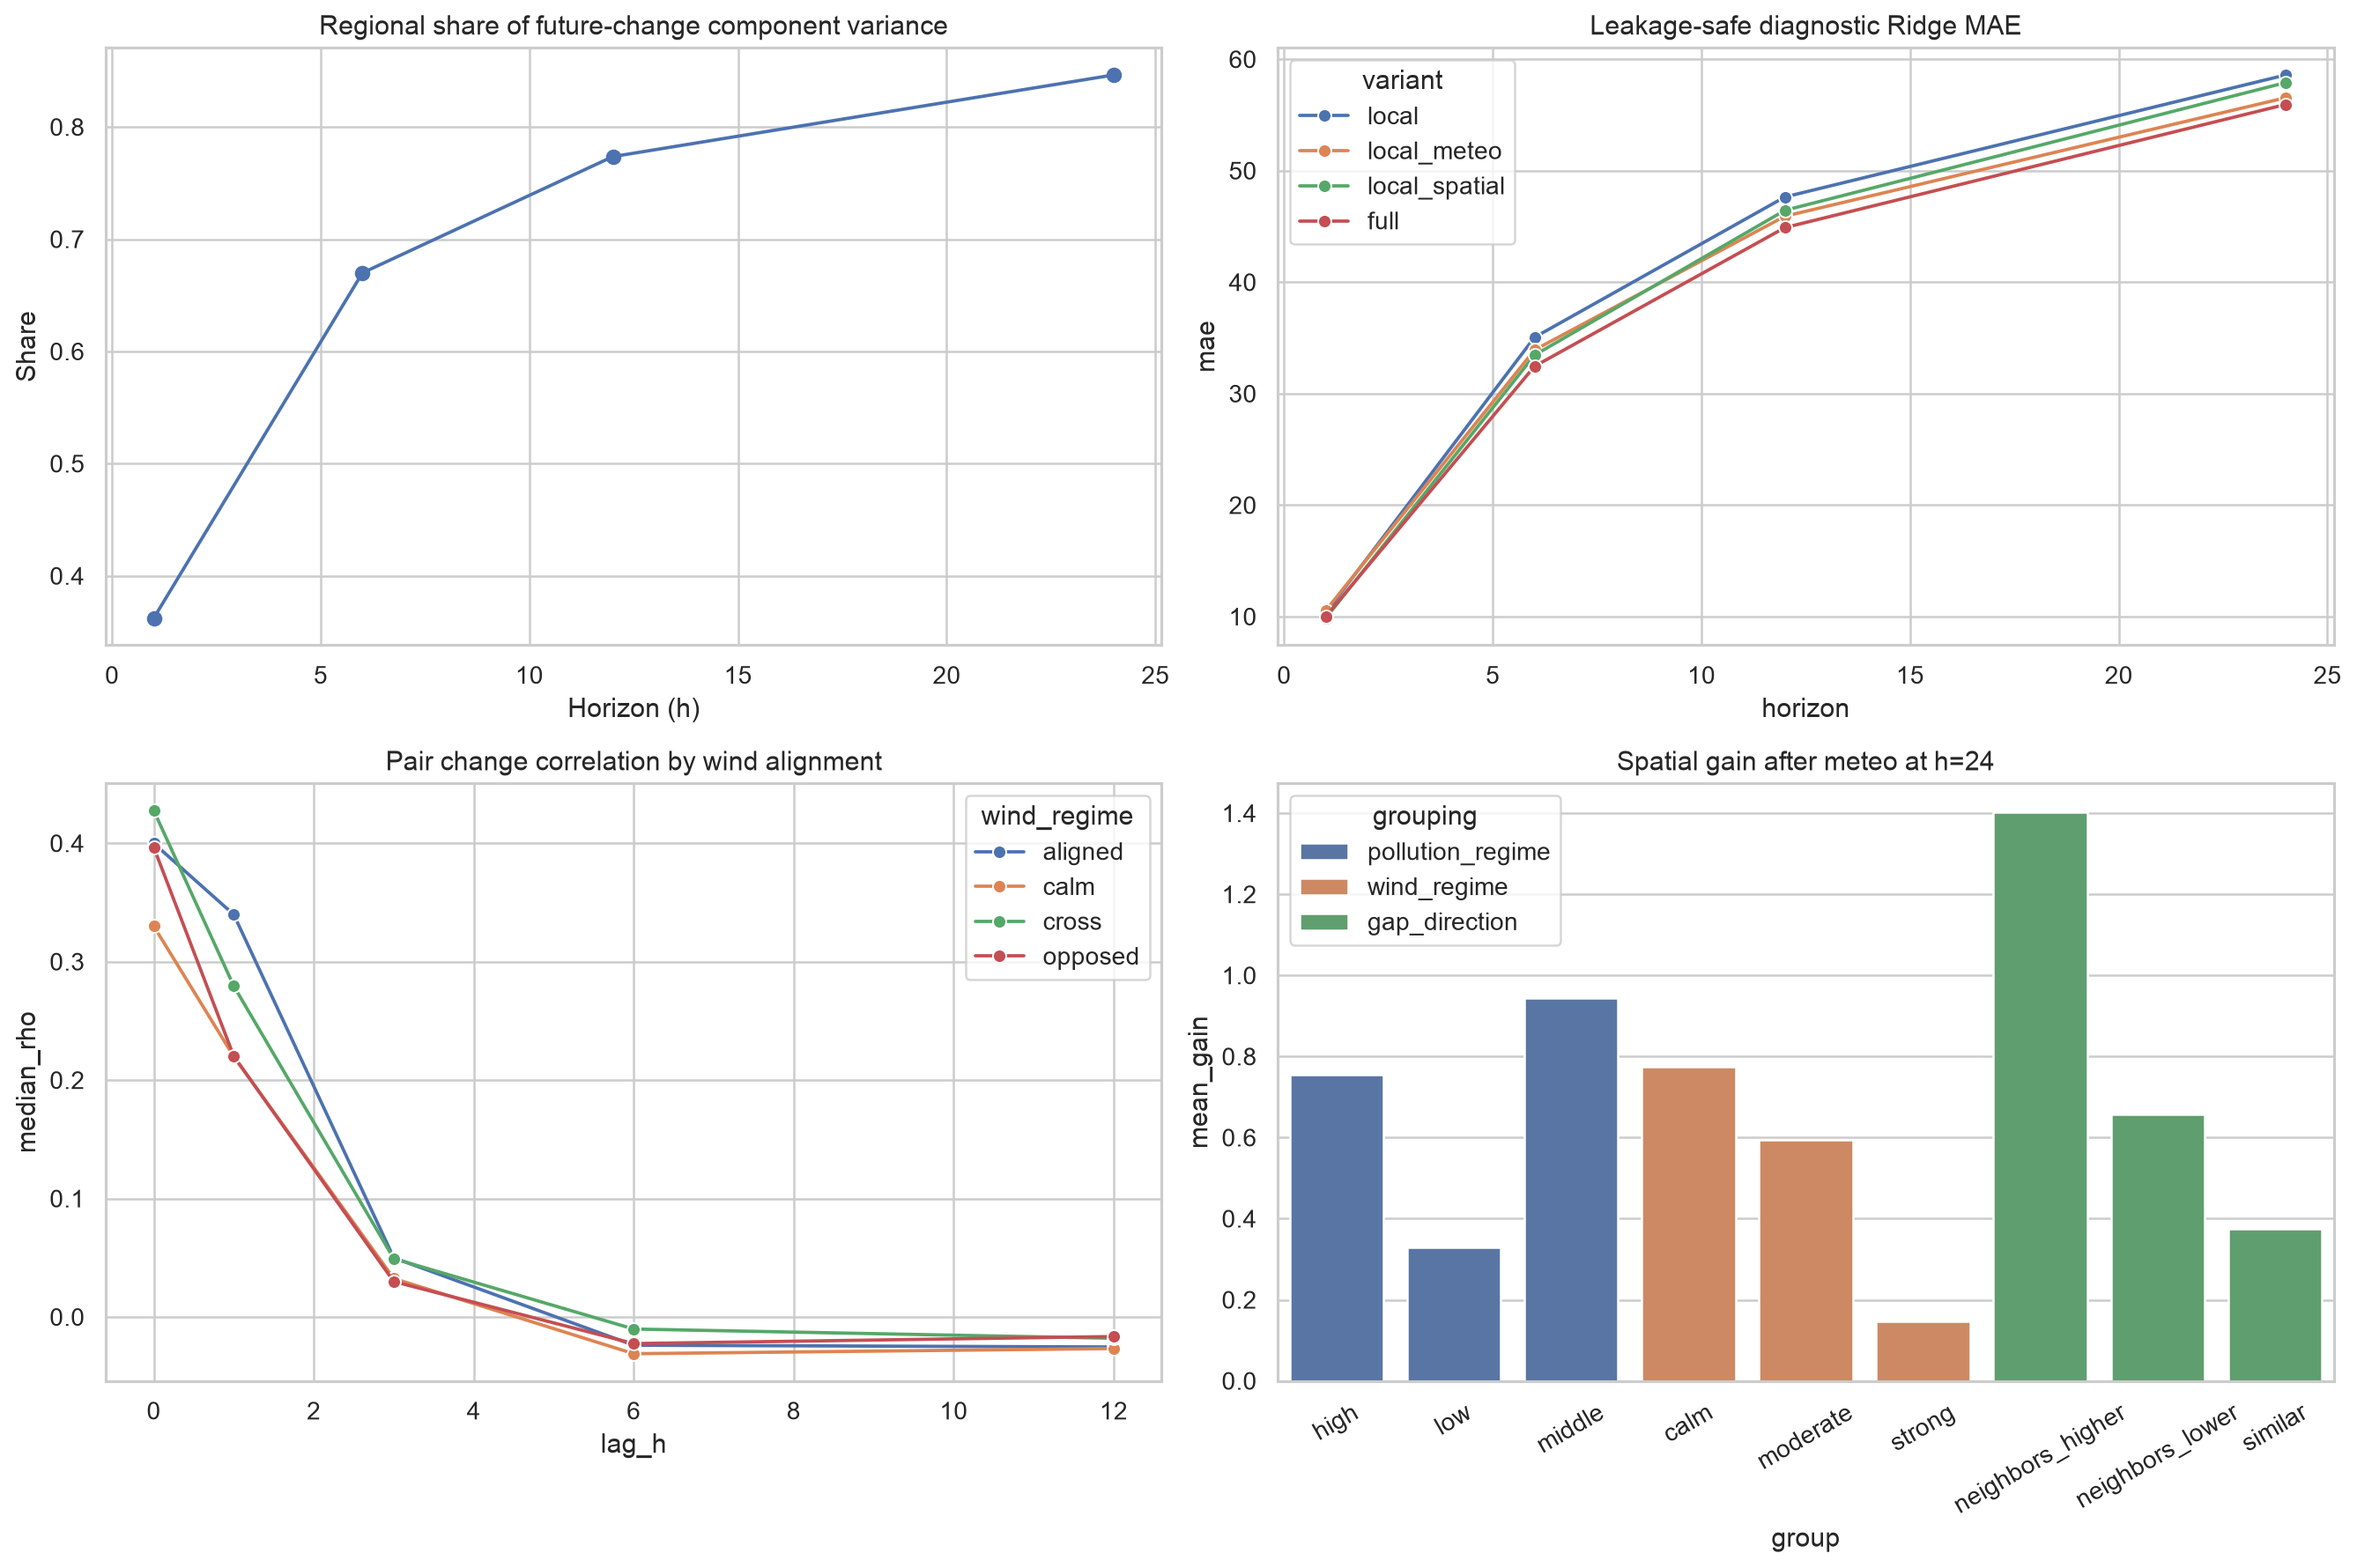

,horizon,total_change_variance,regional_change_variance,local_change_variance,regional_share_of_component_variance
0,1,403.981,147.859,260.121,0.362
1,6,3021.267,2026.080,997.792,0.670
2,12,5229.245,4043.593,1183.059,0.774
3,24,7692.750,6499.953,1179.517,0.846


,lag_h,count,mean,median,std,positive_pair_fraction
0,0,48,-0.013,-0.020,0.097,0.396
1,1,48,0.109,0.112,0.067,0.917
2,3,48,0.035,0.035,0.049,0.750
3,6,48,-0.000,-0.004,0.033,0.438
4,12,48,-0.006,-0.012,0.027,0.396


,stratum,pair_count,mean,median,std,positive_pair_fraction
0,season:autumn,48,0.108,0.109,0.086,0.896
1,season:spring,48,0.109,0.108,0.062,0.958
2,season:summer,48,0.122,0.105,0.087,0.938
3,season:winter,48,0.100,0.091,0.090,0.833
4,speed:moderate,48,0.105,0.103,0.064,0.938
5,speed:strong,48,0.145,0.152,0.097,0.958
6,split:test,48,0.118,0.118,0.105,0.896
7,split:train,48,0.107,0.109,0.062,0.938
8,split:val,48,0.115,0.105,0.087,0.896


,horizon,variant,n,mae,rmse
0,1,local,61353,10.341,20.252
1,1,local_meteo,61353,10.554,20.140
2,1,local_spatial,61353,9.868,19.147
3,1,full,61353,10.019,19.098
4,6,local,61008,35.054,56.790
5,6,local_meteo,61008,33.921,55.721
6,6,local_spatial,61008,33.456,54.456
7,6,full,61008,32.455,53.637
8,12,local,60768,47.648,71.291
9,12,local_meteo,60768,45.920,69.902


In [7]:
from benchmark_eda.deep_eda import run_deep_eda
from IPython.display import Image

deep_dir = ROOT / "artifacts/deep_eda_uci"
deep_summary = run_deep_eda(raw_dir, ROOT / "data/metadata/uci_beijing_station_coords.csv", deep_dir)
regional = pd.read_csv(deep_dir / "regional_local_variance.csv")
pairwise = pd.read_csv(deep_dir / "pairwise_functional_graph.csv")
spikes = pd.read_csv(deep_dir / "spike_episodes.csv")
ridge = pd.read_csv(deep_dir / "diagnostic_ridge_ablation.csv")
spatial_gain = pd.read_csv(deep_dir / "spatial_gain_by_regime.csv")
wind_contrast = pd.read_csv(deep_dir / "wind_alignment_contrast.csv")
wind_robustness = pd.read_csv(deep_dir / "wind_alignment_robustness.csv")

display(Image(filename=str(deep_dir / "deep_eda_main.png"), width=1050))
display(regional.round(3))
display(wind_contrast.round(3))
display(wind_robustness.round(3))
display(ridge.round(3))

## Deep EDA sau khi khóa mô hình

Phần này đi xa hơn correlation toàn cục và kiểm tra trực tiếp các
giả thuyết kiến trúc. Split 70/15/15 vẫn theo thời gian; mọi threshold,
imputation và scaler của diagnostic Ridge chỉ được fit trên train.

- **Regional–local decomposition:** tách biến thiên của future change
  thành thành phần city-wide và residual riêng từng trạm.
- **Functional graph:** so KNN địa lý với top-neighbour theo residual
  change, sau khi bỏ city-wide factor.
- **Event structure:** phân biệt spike cô lập, cluster và regional.
- **Wind-conditioned pair lag:** với mỗi directed geographic edge,
  so correlation source→target khi gió thổi cùng hướng và ngược hướng.
- **Conditional incremental value:** Ridge chỉ đóng vai trò probe tuyến
  tính để hỏi spatial context có ích ở regime nào, không phải baseline
  cạnh tranh với neural model.

In [8]:
regional_share = regional.set_index("horizon").regional_share_of_component_variance
lag1 = wind_contrast.set_index("lag_h").loc[1]
knn_overlap = deep_summary["regional_functional_graph"][
    "geographic_knn_overlap_with_functional_top4_mean"
]
spike_share = deep_summary["spike_missingness"][
    "active_spike_hour_category_share"
]
peripheral_overlap = pd.Series(
    deep_summary["regional_functional_graph"]["geographic_knn_overlap_by_station"]
).sort_values()
top_gain = spatial_gain.sort_values("mean_gain", ascending=False).head(12)

display(Markdown(f'''
### Các quan sát mới

1. **Bài toán đổi bản chất theo horizon.** Regional share tăng từ
   **{regional_share.loc[1]:.1%} ở +1h** lên **{regional_share.loc[24]:.1%} ở +24h**.
   Vì vậy một spatial block giống nhau cho mọi horizon là giả định quá mạnh.
2. **Địa lý là prior tốt nhưng chưa đủ cho mọi trạm.** Mean overlap giữa geographic
   KNN và functional top-4 là **{knn_overlap:.1%}**; thấp nhất ở
   **{peripheral_overlap.index[0]} ({peripheral_overlap.iloc[0]:.0%})** và
   **{peripheral_overlap.index[1]} ({peripheral_overlap.iloc[1]:.0%})**.
3. **Gió không tạo một dynamic graph chung cho mọi lag.** Quan hệ mạnh nhất vẫn
   đồng thời ở hầu hết edge. Tuy nhiên tại lag +1h, aligned-minus-opposed rho là
   **{lag1['mean']:.3f}**, dương ở **{lag1['positive_pair_fraction']:.1%} edge**;
   hiệu ứng xuất hiện lại ở cả train/val/test, bốn mùa và hai mức wind speed.
4. **Spike gồm hai cơ chế.** Trong active spike-hours,
   **{spike_share['regional_6_12']:.1%}** là regional nhưng
   **{spike_share['isolated_1_2']:.1%}** chỉ xảy ra ở 1–2 trạm.
5. **Spatial value có điều kiện.** Probe tuyến tính cho thấy gain lớn nhất quanh
   +6h, khi spatial gap lớn, pollution cao, mùa đông và ở một số trạm ngoại vi.
   Đây là bằng chứng cho gating theo regime, không phải cho graph phức tạp hơn.
'''))
display(top_gain.round(3))


### Các quan sát mới

1. **Bài toán đổi bản chất theo horizon.** Regional share tăng từ
   **36.2% ở +1h** lên **84.6% ở +24h**.
   Vì vậy một spatial block giống nhau cho mọi horizon là giả định quá mạnh.
2. **Địa lý là prior tốt nhưng chưa đủ cho mọi trạm.** Mean overlap giữa geographic
   KNN và functional top-4 là **70.8%**; thấp nhất ở
   **Changping (25%)** và
   **Shunyi (25%)**.
3. **Gió không tạo một dynamic graph chung cho mọi lag.** Quan hệ mạnh nhất vẫn
   đồng thời ở hầu hết edge. Tuy nhiên tại lag +1h, aligned-minus-opposed rho là
   **0.109**, dương ở **91.7% edge**;
   hiệu ứng xuất hiện lại ở cả train/val/test, bốn mùa và hai mức wind speed.
4. **Spike gồm hai cơ chế.** Trong active spike-hours,
   **54.2%** là regional nhưng
   **27.9%** chỉ xảy ra ở 1–2 trạm.
5. **Spatial value có điều kiện.** Probe tuyến tính cho thấy gain lớn nhất quanh
   +6h, khi spatial gap lớn, pollution cao, mùa đông và ở một số trạm ngoại vi.
   Đây là bằng chứng cho gating theo regime, không phải cho graph phức tạp hơn.


,horizon,grouping,group,n,mean_gain,median_gain,fraction_helped
51,6,gap_direction,neighbors_higher,11308,2.851,2.332,0.558
50,6,gap_magnitude,large,19140,2.824,2.686,0.563
52,6,gap_direction,neighbors_lower,7832,2.786,3.280,0.570
42,6,pollution_regime,high,7935,2.717,2.123,0.556
35,6,station,Shunyi,5020,2.588,1.237,0.585
78,12,gap_direction,neighbors_higher,11282,2.304,1.722,0.547
28,6,station,Changping,5150,2.200,1.580,0.606
33,6,station,Huairou,5121,2.123,1.098,0.588
77,12,gap_magnitude,large,19087,2.043,1.920,0.549
41,6,season,winter,25250,2.006,0.961,0.572


In [9]:
display(Markdown(f'''
## Kết luận và giả thuyết nghiên cứu

- Future level bị persistence chi phối (`rho(+1h)={level_corr.loc["PM2.5", 1]:.2f}`),
  còn future change yếu và đổi cơ chế theo horizon.
- Dài hạn chủ yếu là regional factor; ngắn hạn mới chứa directional transport
  residual. Kiến trúc nên tách hai cơ chế này thay vì buộc một graph xử lý cả hai.
- Candidate 1: **horizon-conditioned regional/local mixture** — trọng số regional
  tăng theo horizon, local branch giữ transition ngắn hạn.
- Candidate 2: **sparse one-hour wind transport residual** — wind chỉ điều chỉnh
  residual source→target ở lag ngắn, không thay toàn bộ fixed graph.
- Candidate 3: **regime-gated spatial correction** — kích hoạt mạnh hơn khi spatial
  disagreement lớn, mùa đông/high pollution hoặc ở trạm ngoại vi.
- Candidate 4: **dual event objective** — dự báo riêng xác suất isolated/local onset
  và regional episode, bên cạnh concentration MAE.

Các candidate trên là giả thuyết sinh từ dữ liệu, chưa phải novelty claim. Cần
kiểm tra trên benchmark khác và đối chiếu literature trước khi chọn đóng góp chính.
'''))


## Kết luận và giả thuyết nghiên cứu

- Future level bị persistence chi phối (`rho(+1h)=0.96`),
  còn future change yếu và đổi cơ chế theo horizon.
- Dài hạn chủ yếu là regional factor; ngắn hạn mới chứa directional transport
  residual. Kiến trúc nên tách hai cơ chế này thay vì buộc một graph xử lý cả hai.
- Candidate 1: **horizon-conditioned regional/local mixture** — trọng số regional
  tăng theo horizon, local branch giữ transition ngắn hạn.
- Candidate 2: **sparse one-hour wind transport residual** — wind chỉ điều chỉnh
  residual source→target ở lag ngắn, không thay toàn bộ fixed graph.
- Candidate 3: **regime-gated spatial correction** — kích hoạt mạnh hơn khi spatial
  disagreement lớn, mùa đông/high pollution hoặc ở trạm ngoại vi.
- Candidate 4: **dual event objective** — dự báo riêng xác suất isolated/local onset
  và regional episode, bên cạnh concentration MAE.

Các candidate trên là giả thuyết sinh từ dữ liệu, chưa phải novelty claim. Cần
kiểm tra trên benchmark khác và đối chiếu literature trước khi chọn đóng góp chính.


## Standardized cross-benchmark diagnostics

Các bảng dưới đây dùng cùng định nghĩa horizon, station-specific
train p90, train IQR, chronological split và mask-aware correlation.
Chúng giúp phân biệt quan sát lặp lại giữa benchmark với đặc điểm chỉ
có ở dataset này. Kết quả là mô tả dữ liệu, không phải causal claim
hay quyết định kiến trúc.

`spatial_gap_partial_current` quan trọng hơn raw spatial-gap
correlation vì đã giảm tương quan cơ học do cả spatial gap và target
change cùng chứa giá trị PM hiện tại.

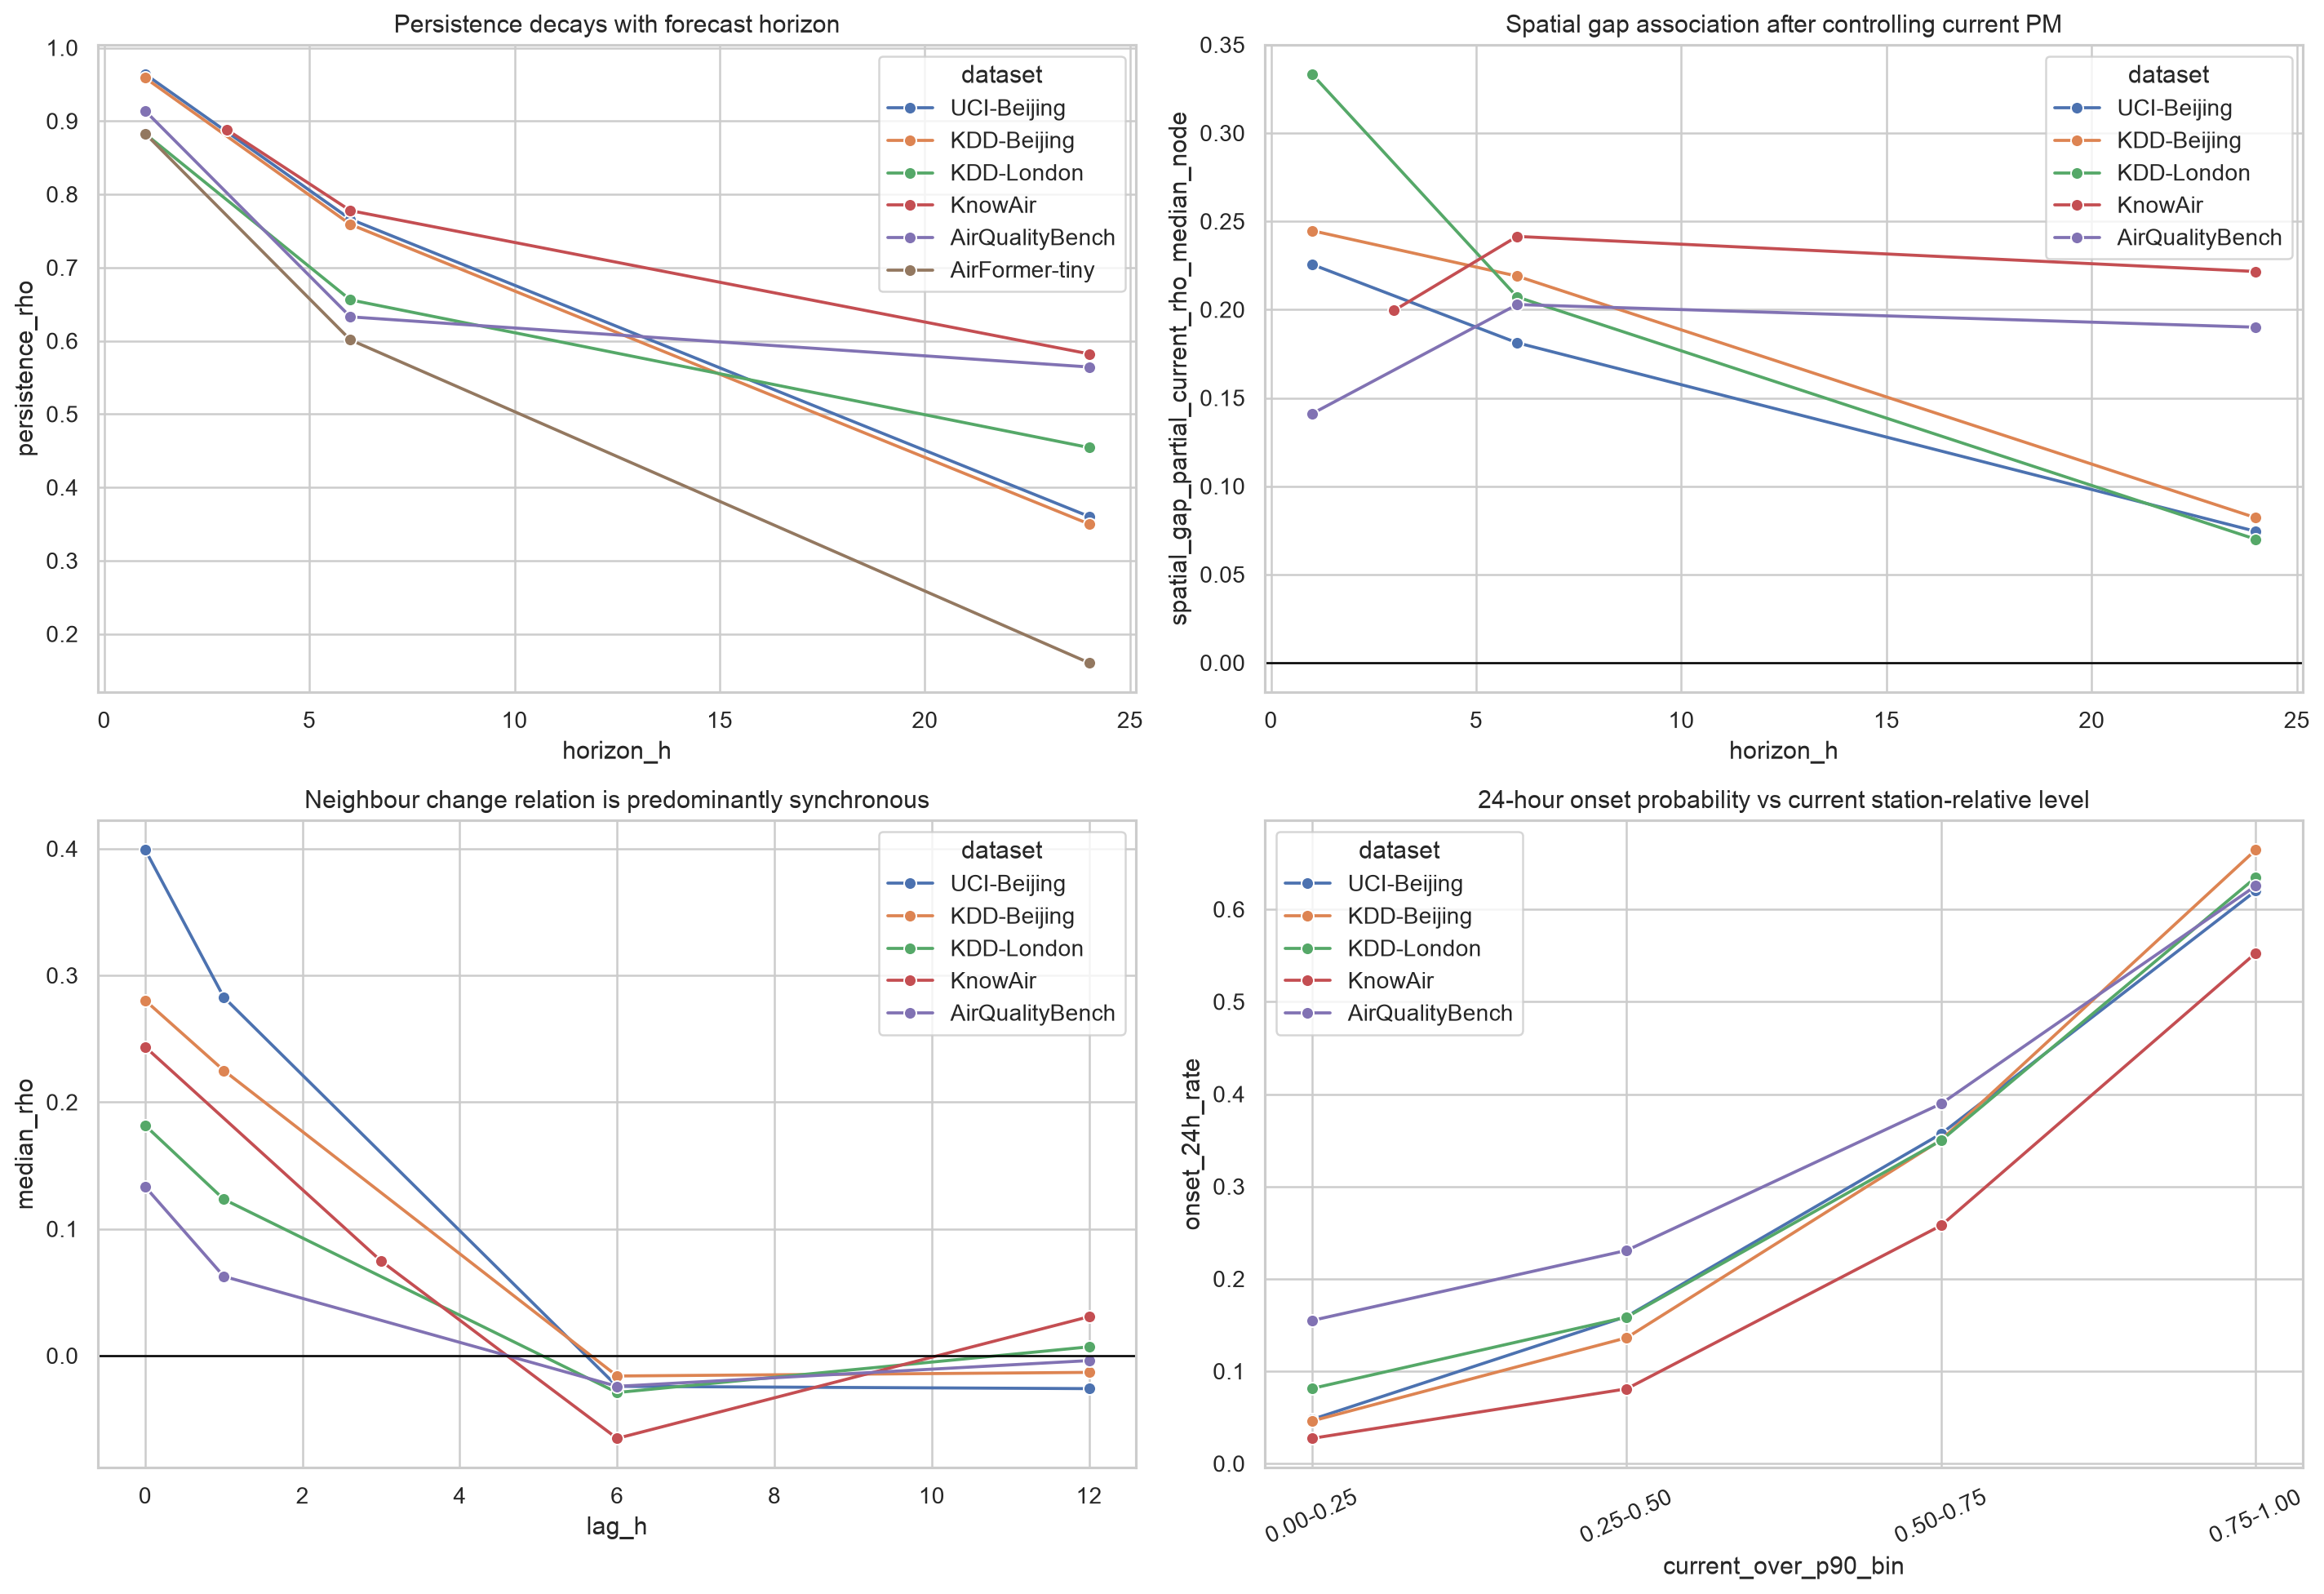

,dataset,scope,time_steps,nodes,cadence_h,start,end,coverage_mean,coverage_node_p10,coverage_node_p90,pm_p50,pm_p90,pm_p99,tail_p99_over_p90
0,UCI-Beijing,"Beijing city, 12 stations",35064,12,1,2013-03-01 00:00:00,2017-02-28 23:00:00,0.979,0.974,0.982,55.0,185.0,370.0,2.0


,dataset,horizon_h,persistence_rho,persistence_mae_over_train_iqr,current_level_vs_future_change_rho,own_recent_trend_rho_median_node,neighbour_recent_trend_rho_median_node,spatial_gap_rho_median_node,spatial_gap_partial_current_rho_median_node,cross_node_mean_component_share
0,UCI-Beijing,1,0.964,0.064,-0.047,0.210,0.369,0.228,0.226,0.363
1,UCI-Beijing,6,0.766,0.202,-0.200,0.046,0.157,0.212,0.181,0.670
2,UCI-Beijing,24,0.360,0.429,-0.399,-0.042,0.009,0.114,0.074,0.847


,dataset,event_rate_test,local_event_coherence,local_event_expected_if_time_independent,local_event_lift_over_independent,active_node_fraction_median,active_node_fraction_p90,spike_duration_h_median,spike_duration_h_p90,coverage_mean,...,seasonal_amplitude_over_iqr,diurnal_amplitude_over_iqr,weekend_minus_weekday_over_iqr,node_median_spread_over_global_iqr,native_change_up_p99_over_down_p99,test_minus_train_median_over_train_iqr,current_over_p90_bin,n,onset_24h_rate,limitation
0,UCI-Beijing,0.129,0.849,0.135,6.315,0.667,1.0,5.0,25.1,0.979,...,0.319,0.19,0.022,0.071,0.81,-0.044,NaN,NaN,NaN,NaN


,dataset,current_over_p90_bin,n,onset_24h_rate
1,UCI-Beijing,0.00-0.25,182097.0,0.048
2,UCI-Beijing,0.25-0.50,99031.0,0.159
3,UCI-Beijing,0.50-0.75,57531.0,0.357
4,UCI-Beijing,0.75-1.00,31508.0,0.620


,dataset,lag_h,edge_count,median_rho,mean_rho,best_lag_zero_edge_fraction
0,UCI-Beijing,0,48,0.399,0.361,0.979
1,UCI-Beijing,1,48,0.283,0.258,0.979
2,UCI-Beijing,6,48,-0.024,-0.021,0.979
3,UCI-Beijing,12,48,-0.026,-0.023,0.979


,dataset,pair_count,distance_vs_level_rho,distance_vs_native_change_rho
0,UCI-Beijing,66,-0.916,-0.888


,dataset,lag_h,pair_count,mean,median,std,positive_pair_fraction
0,UCI-Beijing,0,48,-0.013,-0.020,0.097,0.396
1,UCI-Beijing,1,48,0.109,0.112,0.067,0.917
2,UCI-Beijing,3,48,0.035,0.035,0.049,0.750
3,UCI-Beijing,6,48,-0.000,-0.004,0.033,0.438
4,UCI-Beijing,12,48,-0.006,-0.012,0.027,0.396


,dataset,pollutant,horizon_h,level_rho_median_node,native_change_rho_median_node,current_pollutant_vs_future_pm_change_rho_median_node,partial_current_pm_rho_median_node
0,UCI-Beijing,PM10,6,0.887,0.621,-0.188,-0.014
1,UCI-Beijing,PM10,24,0.887,0.621,-0.359,-0.005
2,UCI-Beijing,SO2,6,0.489,0.275,-0.028,0.097
3,UCI-Beijing,SO2,24,0.489,0.275,-0.105,0.123
4,UCI-Beijing,NO2,6,0.675,0.391,-0.105,0.040
5,UCI-Beijing,NO2,24,0.675,0.391,-0.188,0.133
6,UCI-Beijing,CO,6,0.838,0.503,-0.167,0.011
7,UCI-Beijing,CO,24,0.838,0.503,-0.310,0.060
8,UCI-Beijing,O3,6,-0.259,-0.118,0.087,0.032
9,UCI-Beijing,O3,24,-0.259,-0.118,0.055,-0.061


,dataset,feature,horizon_h,rho_median_node,partial_current_pm_rho_median_node
0,UCI-Beijing,temperature,6,0.007,0.004
1,UCI-Beijing,temperature,24,-0.072,-0.089
2,UCI-Beijing,pressure,6,0.020,0.004
3,UCI-Beijing,pressure,24,0.163,0.138
4,UCI-Beijing,dewpoint,6,-0.051,-0.004
5,UCI-Beijing,dewpoint,24,-0.176,-0.089
6,UCI-Beijing,precipitation,6,-0.055,-0.062
7,UCI-Beijing,precipitation,24,-0.059,-0.076
8,UCI-Beijing,wind_speed,6,-0.024,-0.110
9,UCI-Beijing,wind_speed,24,0.046,-0.112


In [10]:
from IPython.display import Image

cross_dir = ROOT / "artifacts/cross_dataset_eda"
labels = ['UCI-Beijing']
overview_cross = pd.read_csv(cross_dir / "dataset_overview.csv")
horizon_cross = pd.read_csv(cross_dir / "horizon_signals.csv")
events_cross = pd.read_csv(cross_dir / "events_missingness_shift.csv")
edge_cross = pd.read_csv(cross_dir / "edge_lead_lag.csv")
distance_cross = pd.read_csv(cross_dir / "distance_decay_summary.csv")
wind_cross = pd.read_csv(cross_dir / "wind_alignment_replication.csv")
coupling_cross = pd.read_csv(cross_dir / "pollutant_coupling.csv")
meteo_cross = pd.read_csv(cross_dir / "meteorology_precursors.csv")

display(Image(filename=str(cross_dir / "cross_dataset_main.png"), width=1100))
display(overview_cross.query("dataset in @labels").round(3))
display(horizon_cross.query("dataset in @labels").round(3))
display(events_cross.query("dataset in @labels and current_over_p90_bin != current_over_p90_bin").round(3))
display(events_cross.query("dataset in @labels and current_over_p90_bin == current_over_p90_bin")[[
    "dataset", "current_over_p90_bin", "n", "onset_24h_rate"
]].round(3))
display(edge_cross.query("dataset in @labels").round(3))
display(distance_cross.query("dataset in @labels").round(3))
display(wind_cross.query("dataset in @labels").round(3))
display(coupling_cross.query("dataset in @labels").round(3))
display(meteo_cross.query("dataset in @labels").round(3))

Báo cáo diễn giải đầy đủ nằm tại
`artifacts/cross_dataset_eda/OBSERVATIONS.md`. Các ô trống có nghĩa là
phép đo không hợp lệ hoặc không khả dụng trên release này; không được
diễn giải thành “không có hiệu ứng”.